<a href="https://colab.research.google.com/github/chauhan-prince/MFDS_classes/blob/main/Bigmart_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load BigMart dataset (replace with your dataset URL)
df = pd.read_csv('https://github.com/akki8087/Big-Mart-Sales/raw/master/Train.csv')

# Display the first few rows of the dataset
print(df.head())


  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999      Medium               Tier

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.isnull().sum()  # return the count of missing values

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [6]:
# replace count with median value
df.fillna(df['Item_Weight'].median(), inplace=True) # inplace = True, the data is m# as outlet_size is categorical data so we replace with mode
df.fillna(df['Outlet_Size'].mode(), inplace=True)
df[['Item_Weight', 'Outlet_Size']].isnull().sum()

,0
Item_Weight,0
Outlet_Size,0


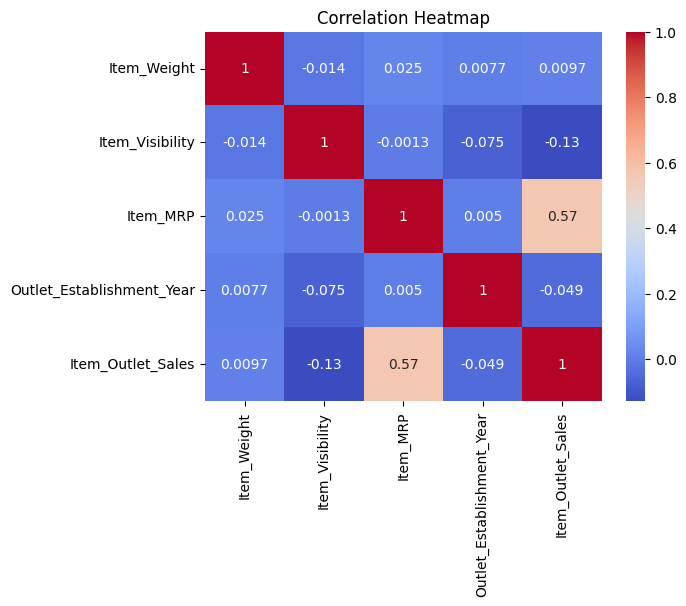

In [8]:
# 1. Correlation Analysis
# perform Bivariate Correlation as data.corr() calculates pairwise correlations bet
corr_matrix = df.corr(numeric_only=True)
# Add numeric_only=True to only include nucorr_matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

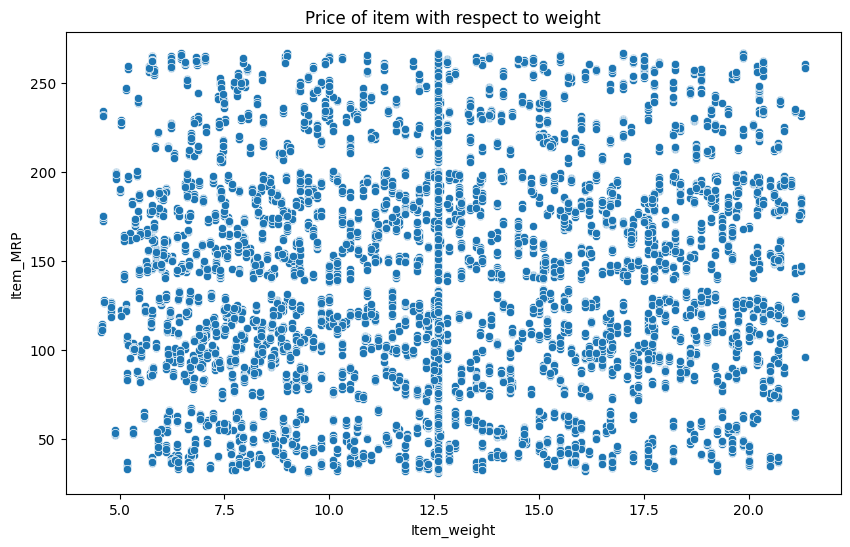

In [9]:
#Observation:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item_Weight', y='Item_MRP', data=df)
plt.title('Price of item with respect to weight')
plt.xlabel('Item_weight')
plt.ylabel('Item_MRP')
plt.show()

Text(0, 0.5, 'Item_Outlet_Sales')

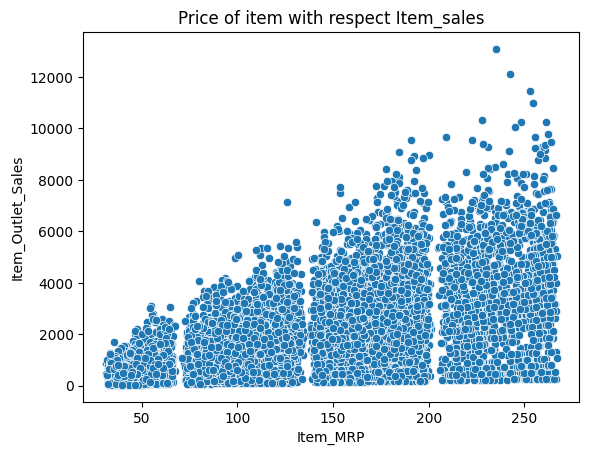

In [10]:
#Observations:
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df)
plt.title('Price of item with respect Item_sales')
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')

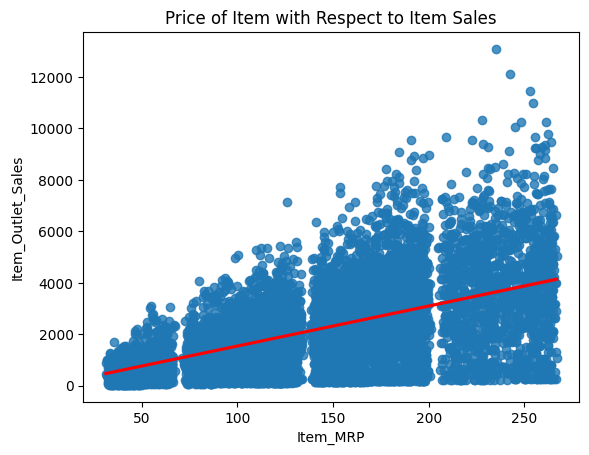

In [12]:
sns.regplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, line_kws={'color': 'red'})

# Add title and labels
plt.title('Price of Item with Respect to Item Sales')
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')

# Show the plot
plt.show()

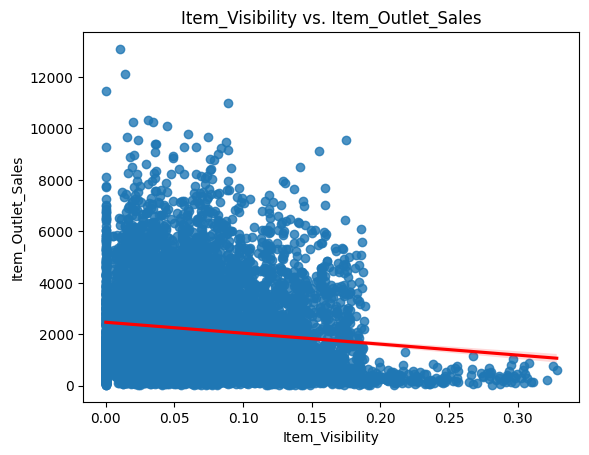

In [13]:
# Item_Weight vs. Item_Outlet_Sales
sns.regplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df, line_kws={'color': 'red'})
plt.title('Item_Visibility vs. Item_Outlet_Sales')
plt.xlabel('Item_Visibility')
plt.ylabel('Item_Outlet_Sales')
plt.show()